# Week 9 Lab — Deep Learning I: CV & CNN with TensorFlow

## 실습 목표
1. **MNIST 이미지 분류**를 통해 딥러닝 비전 실험의 기본 흐름을 익힌다.
2. 이미지를 flatten한 **MLP baseline**과 **CNN baseline**을 비교한다.
3. 왜 CNN이 이미지 구조에 더 잘 맞는지 train / valid 성능으로 확인한다.
4. 마지막에 **CIFAR-10 / Transfer Learning**으로 확장되는 포인트를 짧게 본다.

---

## 오늘 핵심 메시지
- 이미지는 단순 벡터가 아니라 **공간 구조를 가진 입력**이다.
- MLP는 빠른 baseline이 될 수 있지만, CNN은 이미지의 locality를 더 잘 활용한다.
- 이번 실습은 높은 성능보다 **입력 shape, 모델 구조, 학습 곡선 차이**를 이해하는 데 목적이 있다.


> **🗣️ [발표자 스크립트]**  
> "이번 실습에서는 손글씨 숫자 이미지인 MNIST를 사용해서 MLP와 CNN을 비교해보겠습니다.  
> 핵심은 CNN이 무조건 더 복잡한 모델이라는 점이 아니라, 이미지 구조에 더 잘 맞는 inductive bias를 가진다는 점을 확인하는 것입니다."

## 실습 전 준비
- Python 3.10+
- Jupyter Notebook 또는 Colab
- `numpy`, `pandas`, `matplotlib`, `seaborn`, `scikit-learn`
- `tensorflow`


In [3]:
# 필요 패키지 설치 (최초 1회만)
# 로컬 uv 환경 예시
# !uv add numpy pandas matplotlib seaborn scikit-learn tensorflow

# Colab / 일반 Jupyter 환경 예시
# !pip install numpy pandas matplotlib seaborn scikit-learn tensorflow


## 1. 라이브러리 불러오기

In [4]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

try:
    import tensorflow as tf
    from tensorflow import keras
    from tensorflow.keras import layers
except ImportError as e:
    raise ImportError('tensorflow가 설치되어 있지 않습니다. 설치 셀을 먼저 확인하세요.') from e

sns.set_theme(style='whitegrid')
print('TensorFlow version:', tf.__version__)
RANDOM_STATE = 42
tf.keras.utils.set_random_seed(RANDOM_STATE)


TensorFlow version: 2.21.0


## 2. MNIST 데이터 로드

In [5]:
(X_train_full, y_train_full), (X_test, y_test) = keras.datasets.mnist.load_data()

X_train_full = X_train_full.astype('float32') / 255.0
X_test = X_test.astype('float32') / 255.0

X_valid = X_train_full[-10000:]
y_valid = y_train_full[-10000:]
X_train = X_train_full[:-10000]
y_train = y_train_full[:-10000]

print('X_train:', X_train.shape, 'y_train:', y_train.shape)
print('X_valid:', X_valid.shape, 'y_valid:', y_valid.shape)
print('X_test :', X_test.shape, 'y_test :', y_test.shape)


11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
X_train: (50000, 28, 28) y_train: (50000,)
X_valid: (10000, 28, 28) y_valid: (10000,)
X_test : (10000, 28, 28) y_test : (10000,)


## 3. 샘플 이미지 확인

- 이미지 데이터는 항상 **shape**를 먼저 확인하는 습관이 중요하다.
- MNIST는 `(batch, 28, 28)` grayscale 이미지다.


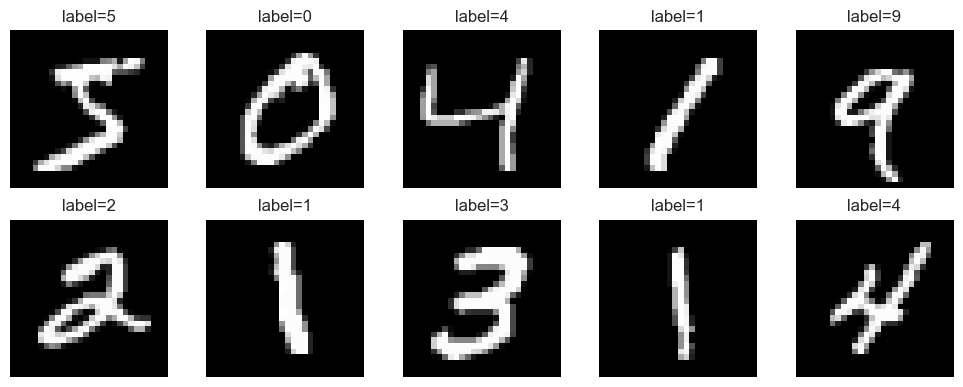

In [6]:
fig, axes = plt.subplots(2, 5, figsize=(10, 4))
for ax, img, label in zip(axes.flatten(), X_train[:10], y_train[:10]):
    ax.imshow(img, cmap='gray')
    ax.set_title(f'label={label}')
    ax.axis('off')
plt.tight_layout()
plt.show()


## 4. MLP baseline용 입력 만들기

- MLP는 이미지를 flatten해서 `(batch, 784)` 형태로 넣는다.
- 이 과정에서 공간 구조를 잃는다는 점이 오늘 비교의 핵심이다.


In [7]:
X_train_mlp = X_train.reshape(len(X_train), -1)
X_valid_mlp = X_valid.reshape(len(X_valid), -1)
X_test_mlp = X_test.reshape(len(X_test), -1)

print('MLP input shape:', X_train_mlp.shape)


MLP input shape: (50000, 784)


## 5. MLP baseline 모델 정의

In [8]:
mlp_model = keras.Sequential([
    layers.Input(shape=(784,)),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.2),
    layers.Dense(128, activation='relu'),
    layers.Dense(10, activation='softmax')
])

mlp_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

mlp_model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 256)            │       200,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 235,146 (918.54 KB)

 Trainable params: 235,146 (918.54 KB)

 Non-trainable params: 0 (0.00 B)

## 6. MLP baseline 학습

In [9]:
early_stop = keras.callbacks.EarlyStopping(
    monitor='val_accuracy',
    patience=2,
    restore_best_weights=True
)

history_mlp = mlp_model.fit(
    X_train_mlp,
    y_train,
    validation_data=(X_valid_mlp, y_valid),
    epochs=8,
    batch_size=128,
    callbacks=[early_stop],
    verbose=1
)


Epoch 1/8
391/391 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9041 - loss: 0.3305 - val_accuracy: 0.9612 - val_loss: 0.1346
Epoch 2/8
391/391 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.9588 - loss: 0.1367 - val_accuracy: 0.9675 - val_loss: 0.1068
Epoch 3/8
391/391 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.9709 - loss: 0.0973 - val_accuracy: 0.9702 - val_loss: 0.0958
Epoch 4/8
391/391 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.9772 - loss: 0.0737 - val_accuracy: 0.9749 - val_loss: 0.0854
Epoch 5/8
391/391 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.9803 - loss: 0.0607 - val_accuracy: 0.9768 - val_loss: 0.0781
Epoch 6/8
391/391 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9830 - loss: 0.0517 - val_accuracy: 0.9779 - val_loss: 0.0744
Epoch 7/8
391/391 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.9859 - loss: 0.0427 - val_accuracy: 0.9772 - val_loss: 0.0772
Epoch 8/8
391/391 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.9873 - loss: 0.0382 - val_accuracy: 0.9745 - v

## 7. CNN baseline용 입력 만들기

- CNN은 `(batch, height, width, channel)` 형태를 사용한다.
- MNIST는 grayscale이므로 마지막 channel 차원을 1로 추가한다.


In [10]:
X_train_cnn = np.expand_dims(X_train, axis=-1)
X_valid_cnn = np.expand_dims(X_valid, axis=-1)
X_test_cnn = np.expand_dims(X_test, axis=-1)

print('CNN input shape:', X_train_cnn.shape)


CNN input shape: (50000, 28, 28, 1)


## 8. CNN baseline 모델 정의

In [11]:
cnn_model = keras.Sequential([
    layers.Input(shape=(28, 28, 1)),
    layers.Conv2D(32, kernel_size=3, activation='relu'),
    layers.MaxPooling2D(pool_size=2),
    layers.Conv2D(64, kernel_size=3, activation='relu'),
    layers.MaxPooling2D(pool_size=2),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(10, activation='softmax')
])

cnn_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

cnn_model.summary()


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 128)            │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 225,034 (879.04 KB)

 Trainable params: 225,034 (879.04 KB)

 Non-trainable params: 0 (0.00 B)

## 9. CNN baseline 학습

In [12]:
history_cnn = cnn_model.fit(
    X_train_cnn,
    y_train,
    validation_data=(X_valid_cnn, y_valid),
    epochs=8,
    batch_size=128,
    callbacks=[early_stop],
    verbose=1
)


Epoch 1/8
391/391 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - accuracy: 0.9054 - loss: 0.3067 - val_accuracy: 0.9766 - val_loss: 0.0812
Epoch 2/8
391/391 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.9747 - loss: 0.0848 - val_accuracy: 0.9825 - val_loss: 0.0575
Epoch 3/8
391/391 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.9814 - loss: 0.0594 - val_accuracy: 0.9878 - val_loss: 0.0446
Epoch 4/8
391/391 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.9860 - loss: 0.0466 - val_accuracy: 0.9889 - val_loss: 0.0380
Epoch 5/8
391/391 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.9883 - loss: 0.0361 - val_accuracy: 0.9869 - val_loss: 0.0425
Epoch 6/8
391/391 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.9903 - loss: 0.0319 - val_accuracy: 0.9885 - val_loss: 0.0393


## 10. MLP vs CNN 학습 곡선 비교

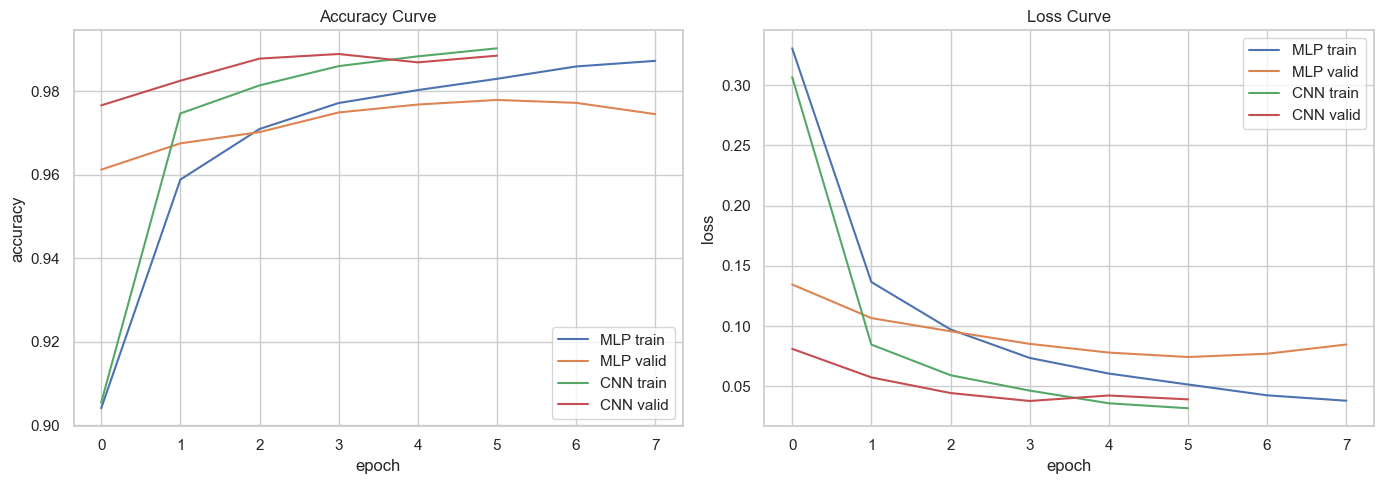

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history_mlp.history['accuracy'], label='MLP train')
axes[0].plot(history_mlp.history['val_accuracy'], label='MLP valid')
axes[0].plot(history_cnn.history['accuracy'], label='CNN train')
axes[0].plot(history_cnn.history['val_accuracy'], label='CNN valid')
axes[0].set_title('Accuracy Curve')
axes[0].set_xlabel('epoch')
axes[0].set_ylabel('accuracy')
axes[0].legend()

axes[1].plot(history_mlp.history['loss'], label='MLP train')
axes[1].plot(history_mlp.history['val_loss'], label='MLP valid')
axes[1].plot(history_cnn.history['loss'], label='CNN train')
axes[1].plot(history_cnn.history['val_loss'], label='CNN valid')
axes[1].set_title('Loss Curve')
axes[1].set_xlabel('epoch')
axes[1].set_ylabel('loss')
axes[1].legend()

plt.tight_layout()
plt.show()


## 11. 평가 함수 정의

In [14]:
def evaluate_keras_classifier(model, X_train, X_valid, X_test, y_train, y_valid, y_test, model_name):
    train_prob = model.predict(X_train, verbose=0)
    valid_prob = model.predict(X_valid, verbose=0)
    test_prob = model.predict(X_test, verbose=0)

    train_pred = np.argmax(train_prob, axis=1)
    valid_pred = np.argmax(valid_prob, axis=1)
    test_pred = np.argmax(test_prob, axis=1)

    return {
        'model': model_name,
        'train_accuracy': accuracy_score(y_train, train_pred),
        'valid_accuracy': accuracy_score(y_valid, valid_pred),
        'test_accuracy': accuracy_score(y_test, test_pred)
    }


## 12. 최종 성능 비교

In [15]:
mlp_result = evaluate_keras_classifier(
    mlp_model, X_train_mlp, X_valid_mlp, X_test_mlp, y_train, y_valid, y_test, 'MLP baseline'
)
cnn_result = evaluate_keras_classifier(
    cnn_model, X_train_cnn, X_valid_cnn, X_test_cnn, y_train, y_valid, y_test, 'CNN baseline'
)

comparison_df = pd.DataFrame([mlp_result, cnn_result])
comparison_df.style.format({
    'train_accuracy': '{:.4f}',
    'valid_accuracy': '{:.4f}',
    'test_accuracy': '{:.4f}'
})


,model,train_accuracy,valid_accuracy,test_accuracy
0,MLP baseline,0.9914,0.9779,0.9791
1,CNN baseline,0.9922,0.9889,0.9892


## 13. 테스트셋 예측과 오분류 확인

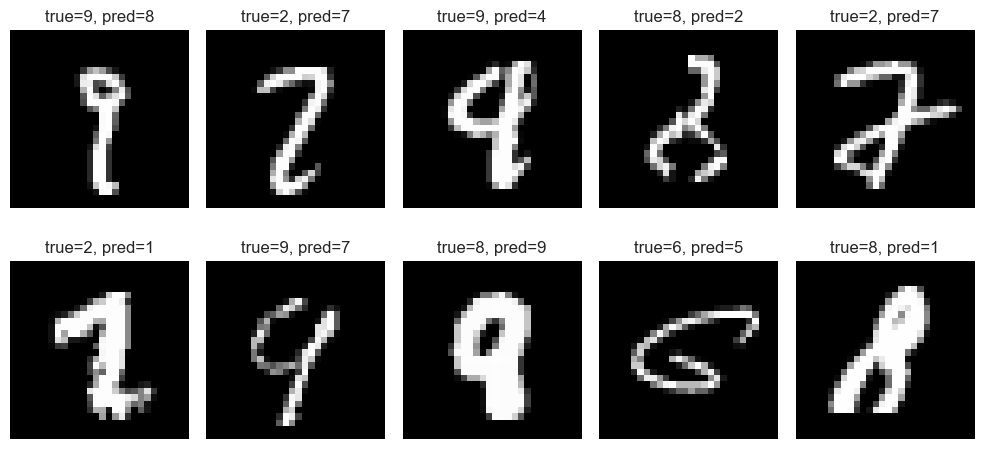

              precision    recall  f1-score   support

           0       0.99      1.00      0.99       980
           1       0.99      1.00      0.99      1135
           2       0.99      0.99      0.99      1032
           3       0.99      0.99      0.99      1010
           4       0.99      1.00      0.99       982
           5       0.99      0.98      0.99       892
           6       0.99      0.99      0.99       958
           7       0.98      0.99      0.99      1028
           8       0.99      0.98      0.99       974
           9       0.99      0.97      0.98      1009

    accuracy                           0.99     10000
   macro avg       0.99      0.99      0.99     10000
weighted avg       0.99      0.99      0.99     10000



In [16]:
test_prob_cnn = cnn_model.predict(X_test_cnn, verbose=0)
test_pred_cnn = np.argmax(test_prob_cnn, axis=1)

mis_idx = np.where(test_pred_cnn != y_test)[0][:10]

fig, axes = plt.subplots(2, 5, figsize=(10, 5))
for ax, idx in zip(axes.flatten(), mis_idx):
    ax.imshow(X_test[idx], cmap='gray')
    ax.set_title(f'true={y_test[idx]}, pred={test_pred_cnn[idx]}')
    ax.axis('off')
plt.tight_layout()
plt.show()

print(classification_report(y_test, test_pred_cnn))


## 14. CIFAR-10은 왜 더 어려운가

- CIFAR-10은 컬러 이미지이며 배경 다양성이 더 크다.
- 따라서 MNIST보다 더 깊은 CNN, augmentation, pretrained model 필요성이 커진다.
- 아래 셀은 데이터셋 형태만 가볍게 확인하는 용도다.


CIFAR-10 다운로드 또는 로드에 실패했습니다.
원인: URL fetch failure on https://www.cs.toronto.edu/~kriz/cifar-10-python.tar.gz: 503 -- Service Unavailable
수업 진행용 대체 예시로 Fashion-MNIST sample을 표시합니다.
29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Fashion-MNIST train shape: (60000, 28, 28)
Fashion-MNIST test shape : (10000, 28, 28)


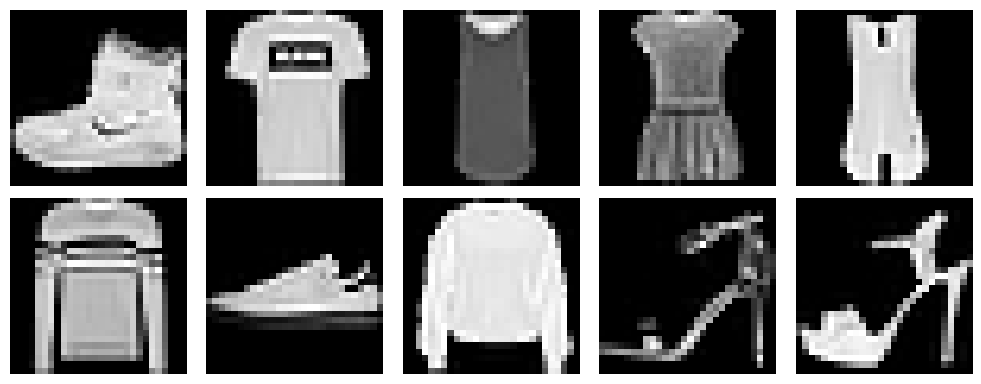

In [19]:
try:
    (X_train_cifar, y_train_cifar), (X_test_cifar, y_test_cifar) = keras.datasets.cifar10.load_data()
    print('CIFAR-10 train shape:', X_train_cifar.shape)
    print('CIFAR-10 test shape :', X_test_cifar.shape)

    fig, axes = plt.subplots(2, 5, figsize=(10, 4))
    for ax, img in zip(axes.flatten(), X_train_cifar[:10]):
        ax.imshow(img)
        ax.axis('off')
    plt.tight_layout()
    plt.show()
except Exception as e:
    print('CIFAR-10 다운로드 또는 로드에 실패했습니다.')
    print('원인:', e)
    print('수업 진행용 대체 예시로 Fashion-MNIST sample을 표시합니다.')

    (X_train_fashion, y_train_fashion), (X_test_fashion, y_test_fashion) = keras.datasets.fashion_mnist.load_data()
    print('Fashion-MNIST train shape:', X_train_fashion.shape)
    print('Fashion-MNIST test shape :', X_test_fashion.shape)

    fig, axes = plt.subplots(2, 5, figsize=(10, 4))
    for ax, img in zip(axes.flatten(), X_train_fashion[:10]):
        ax.imshow(img, cmap='gray')
        ax.axis('off')
    plt.tight_layout()
    plt.show()


## 15. Transfer Learning으로 이어지는 한 줄

- MNIST에서는 작은 CNN만으로도 충분했지만,
- CIFAR-10이나 실제 이미지 문제에서는 **pretrained backbone + fine-tuning** 전략이 훨씬 실용적이다.
- 다음 단계에서는 ResNet 같은 pretrained model을 가져와 feature extractor 또는 fine-tuning 방식으로 쓸 수 있다.


## 16. 실습 해석 가이드

### 확인할 포인트
1. MLP와 CNN의 입력 shape은 어떻게 달랐는가?
2. CNN이 validation / test 기준에서 왜 더 유리했는가?
3. accuracy 차이뿐 아니라 learning curve 모양도 어떻게 달랐는가?
4. CIFAR-10으로 가면 왜 더 복잡한 backbone이 필요해지는가?
5. 여기서 Transfer Learning이 왜 자연스럽게 등장하는가?

### 한 줄 정리
- **CNN은 이미지 구조를 살려 학습하고, Transfer Learning은 그 구조 학습 결과를 재사용한다.**
